# Module 2 — Predicting reported biodiversity impact (biomass / above-ground C) of SLM technologies with neural networks

**Research question.** `research.md` frames Module 2 as a supervised problem: which features of SLM
technologies predict a *high* versus a *low* improvement in biodiversity? It also fixes the output —
**biomass / above-ground C** (questionnaire section 6.1), the indicator WOCAT is primarily interested
in, split at the median — and lists the input fields. This notebook follows that specification and
adds the half that matters most to WOCAT: among the documented SLM methods, which ones go together
with the largest reported biomass gains once we account for where they are applied?

**What this notebook builds on**

* Dima's data exploration (`colab/01_wocat_explore.ipynb`) gave us the tidy tables and three rules
  we follow throughout: split the target at the **median** (84 % of all impact scores are positive),
  **group cross-validation by country** (sites and compilers cluster geographically), and treat the
  scores as **reported** impact, never as causal effect (compiler averages differ by two points on a
  seven-point scale).
* Norman's Module 1 clustering (`module1_kmeans_clustering.ipynb`) showed that the structure of the
  data is dominated by the agro-climatic zone: environment first, practice second.

**What we do here (Module 2)**

1. Three classical **yardsticks** (majority class, logistic regression, random forest — the forest
   also gives `research.md`'s feature importances).
2. **Method 1 — a regularised deep feed-forward network**: He initialisation, batch normalisation,
   dropout, L2, Adam, a learning-rate schedule and early stopping, tuned on a small grid.
3. **Method 2 — a multi-task network** that predicts the biomass high/low label *and* all eight
   biodiversity indicators of section 6.1 at once, with a custom loss that tolerates missing indicators.
4. **A sensitivity check**: what changes with the mean of all eight indicators as the target, or
   with ten questionnaire fields that `research.md` does not list.
5. **The answer**: a what-if analysis with the multi-task network that ranks SLM groups with the
   environment held fixed, a method × indicator heat-map, and a permutation test of which feature
   blocks the network actually uses.

**Key results, in one paragraph.** Following `research.md` pays off: with biomass as the target and
only its input fields, the classical models reach AUC 0.63 on unseen countries (logistic regression
0.629, random forest 0.626), against 0.52–0.56 for the mean of all eight indicators with ten extra
fields. The neural networks do not add to that: averaged over three seeds, the multi-task net
reaches 0.60 and the feed-forward net 0.59, and the seed alone moves a network by several
hundredths. Logistic regression — a network without hidden layers — is the best model. The
individual indicators are not predictable beyond their means. The strongest signal is *how many*
land-degradation types a technology addresses: 17 % of the technologies addressing one type report
the top biomass score, 47 % of those addressing five or more — a trace of how thoroughly the form
is filled in as much as of the land. Ground cover, forest, windbreak and agroforestry lead the
biomass ranking with the environment held fixed; water harvesting, crop–livestock integration and
plantation trail.

Run time: about 12 minutes on a laptop CPU. Kernel: **Python (CAS AML)**.

## 1. Setup

In [1]:
import os, sys, time, math, warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # reproducible numerics on CPU

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import sklearn
import tensorflow as tf
import keras
from keras import layers

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
SEED = 42
keras.utils.set_random_seed(SEED)

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"tensorflow {tf.__version__} | keras {keras.__version__}")

# plotting conventions
C_BLUE, C_ORANGE, C_AQUA, C_RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK_MUTED, GRID, NEUTRAL = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#3987e5", "#0d366b"])
BLUE_RED = LinearSegmentedColormap.from_list("blue_red", ["#104281", "#f0efec", "#b03030"])
plt.rc("font", size=11); plt.rc("axes", titlesize=12, labelsize=11, edgecolor=NEUTRAL, labelcolor=INK, axisbelow=True)
plt.rc("grid", color=GRID, linewidth=0.8); plt.rc("xtick", color=INK_MUTED); plt.rc("ytick", color=INK_MUTED)
plt.rc("legend", frameon=False, fontsize=10); plt.rc("figure", facecolor="white", dpi=100)

def tidy(ax, grid_axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(False)
    if grid_axis:
        ax.grid(True, axis=grid_axis)
    return ax

python 3.13.15 | pandas 3.0.5 | scikit-learn 1.9.0 | tensorflow 2.21.0 | keras 3.15.1


## 2. Data and targets

Two tables from Dima's notebook: one row per technology (1 540 × 51) and one row per individual
impact score (23 802). The biodiversity block of the questionnaire (section 6.1) asks for a −3 … +3
rating of eight indicators; a technology scores only the ones its compiler considered relevant.
`research.md` names one of them as the main output: **biomass / above-ground C**, the indicator
WOCAT is primarily interested in. The other seven are optional outputs.

In [2]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "colab" / "datasets" / "wocat"
        if (candidate / "wocat_technologies.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("run this notebook from inside the CAS-AML-WOCAT repository")

DATA = find_data_dir()
wocat = pd.read_csv(DATA / "wocat_technologies.csv.gz")
scores = pd.read_csv(DATA / "impact_scores.csv.gz")

PRETTY = {"vegetation_cover": "Vegetation cover", "biomass_above_ground_C": "Biomass / above-ground C",
          "plant_diversity": "Plant diversity", "animal_diversity": "Animal diversity",
          "beneficial_species": "Beneficial species", "habitat_diversity": "Habitat diversity",
          "invasive_alien_species": "Invasive alien species", "pest_disease_control": "Pest / disease control"}
BIO = list(PRETTY)
TARGET = "biomass_above_ground_C"          # research.md: the main output variable

bio_wide = (scores[scores["block"] == "ecological_biodiversity"]
            .pivot_table(index="technology_id", columns="indicator", values="value", aggfunc="mean").reindex(columns=BIO))
bio_all = wocat.merge(bio_wide, left_on="technology_id", right_index=True, how="inner").reset_index(drop=True)
bio_all["bio_mean"] = bio_all[BIO].mean(axis=1)                  # the secondary target of section 7.2
data = bio_all[bio_all[TARGET].notna()].reset_index(drop=True)   # the technologies that score biomass
MEDIAN = data[TARGET].median()
data["bio_high"] = (data[TARGET] > MEDIAN).astype(int)
y = data["bio_high"].to_numpy()
Y_IND = data[BIO].to_numpy(dtype=np.float32)          # NaN where an indicator was not scored

print(f"{len(wocat):,} technologies, {len(scores):,} individual scores; {len(bio_all)} technologies score at least one "
      f"biodiversity indicator, {len(data)} of them score biomass / above-ground C")
print(f"biomass score: median = {MEDIAN:+.0f}; share above the median ('high') = {y.mean():.2f}; "
      f"share at or above the median = {(data[TARGET] >= MEDIAN).mean():.2f}\n")
scored = bio_all[BIO].notna()
print(pd.DataFrame({"scored (all 895)": scored.sum().values, f"scored (the {len(data)} biomass records)": data[BIO].notna().sum().values,
                    "mean score": bio_all[BIO].mean().round(2).values, "share > 0": ((bio_all[BIO] > 0).sum() / scored.sum()).round(2).values},
                   index=[PRETTY[b] for b in BIO]).to_string())

1,540 technologies, 23,802 individual scores; 895 technologies score at least one biodiversity indicator, 479 of them score biomass / above-ground C
biomass score: median = +2; share above the median ('high') = 0.30; share at or above the median = 0.68

                          scored (all 895)  scored (the 479 biomass records)  mean score  share > 0
Vegetation cover                       350                               200        1.86       0.96
Biomass / above-ground C               479                               479        1.92       0.95
Plant diversity                        475                               291        1.75       0.93
Animal diversity                       249                               157        1.52       0.89
Beneficial species                     281                               175        1.64       0.94
Habitat diversity                      338                               208        1.54       0.88
Invasive alien species                  98    

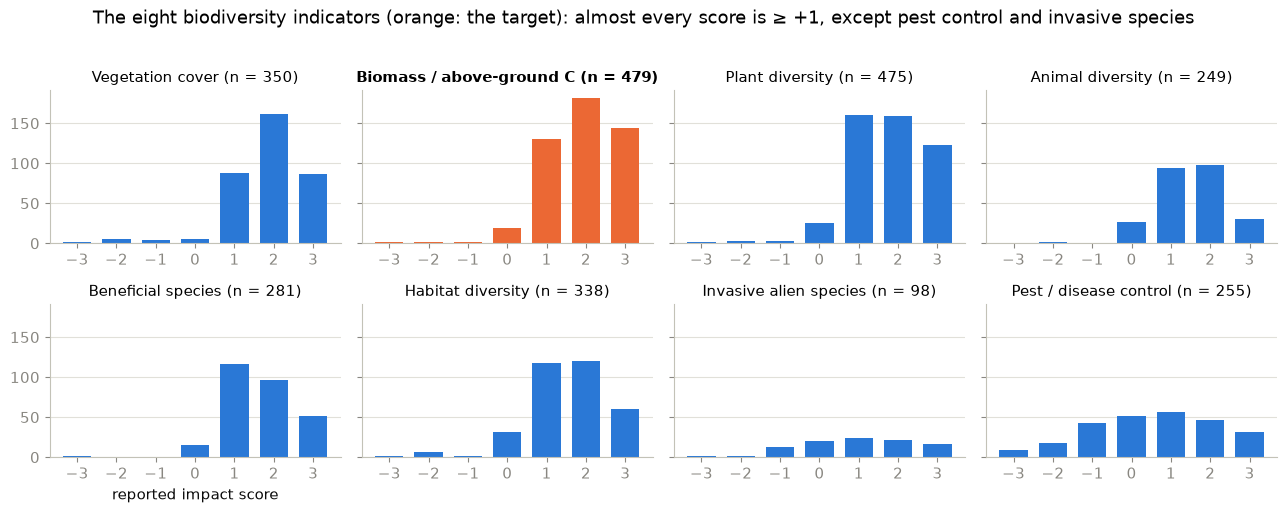

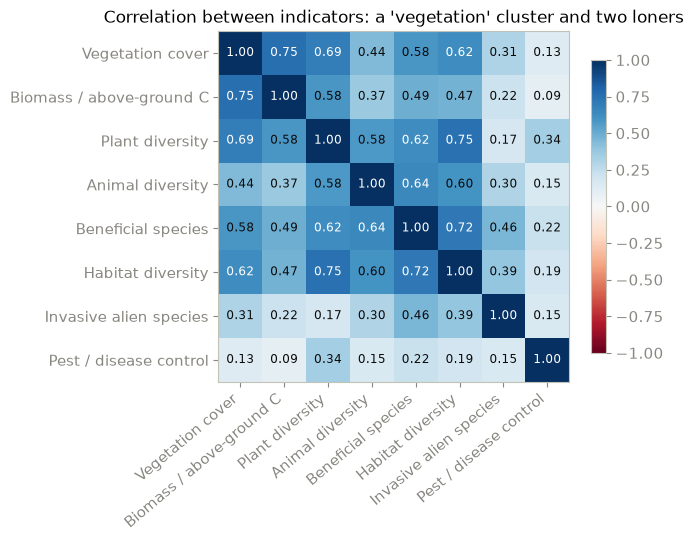

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=True)
for ax, b in zip(axes.ravel(), BIO):
    counts = bio_all[b].round().value_counts().reindex(range(-3, 4), fill_value=0)
    ax.bar(counts.index, counts.values, color=C_ORANGE if b == TARGET else C_BLUE, width=0.72)
    ax.set_title(f"{PRETTY[b]} (n = {int(bio_all[b].notna().sum())})", fontsize=10.5, fontweight="bold" if b == TARGET else "normal")
    ax.set_xticks(range(-3, 4)); tidy(ax)
axes[1, 0].set_xlabel("reported impact score")
fig.suptitle("The eight biodiversity indicators (orange: the target): almost every score is ≥ +1, except pest control and invasive species", y=1.02)
plt.tight_layout(); plt.show()

corr = bio_all[BIO].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(corr.values, cmap="RdBu", vmin=-1, vmax=1)
labels = [PRETTY[b] for b in BIO]
ax.set_xticks(range(8), labels, rotation=40, ha="right"); ax.set_yticks(range(8), labels)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8.5, color="white" if abs(corr.values[i, j]) > 0.6 else INK)
ax.set_title("Correlation between indicators: a 'vegetation' cluster and two loners"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Target.** `bio_high` = 1 if a technology's biomass / above-ground C score is above the median, as
`research.md` asks. The scores are whole numbers and the median is +2, a step that alone holds 38 %
of the records, so any median split puts that whole step on one side. "Above the median" means the
**top rating +3 against +2 or less**: 144 high against 335 low, a 30 / 70 split. "At or above the
median" would call +2 high as well (68 / 32), and splitting at zero would give 95 / 5. We keep the
strict rule, the convention of the earlier version of this notebook; section 7.2 reports the other
split.

**Imbalance.** AUC stays the headline metric: it depends neither on a threshold nor on the class
balance. For macro-F1 and balanced accuracy a model calls a record "high" when its probability
exceeds the share of high records in its training fold (≈ 0.30), not 0.5, which would call almost
everything low. We do not use class weights: they would shift the decision the same way but distort
the predicted probabilities, and section 7.3 reads those probabilities directly.

Only 479 of the 895 technologies with a biodiversity score rate biomass, so every model below trains
and tests on those 479. The eight indicator columns (`NaN` where not scored) are the extra targets
of the multi-task network; their mean, the target of the earlier version, returns in section 7.2.

## 3. Features and the country-grouped split

The inputs are the Module 2 fields of `research.md`, as far as Dima's table contains them, one-hot or
multi-hot encoded (82 binary features):

| `research.md` field (questionnaire section) | role in `research.md` | used here |
|---|---|---|
| SLM group (3.5) | essential | ✅ `slm_group`, multi-answer |
| SLM measures (3.6) | essential | ✅ `measures`, multi-answer |
| Land degradation addressed (3.7) | essential | ✅ `degradation`, multi-answer |
| Groundwater table (5.4) | essential | ❌ not in the table (API key `groundwater`) |
| Availability of surface water | essential | ❌ not in the table (`surfacewater`) |
| Cost of establishment (4.4) and maintenance (4.6) | essential | ❌ not in the table (`establishment_cost_breakdown`, `maintenance_cost_breakdown`, local currencies) |
| Main purpose (3.1) | optional | ✅ `main_purpose`, multi-answer |
| Current land use | optional | ✅ `landuse`, multi-answer |
| Water supply | optional | ✅ `watersupply` |
| Agro-climatic zone (5.1) | optional | ✅ `agroclimatic_zone` |
| Slope (6.2) | optional | ✅ `slope` |
| Land use before the Technology (3.3) | optional | ❌ not in the table (`landuse_change`) |
| Tillage system (3.6) | optional | ❌ not in the table (`agronomic_tillage`) |
| Prevent / reduce / restore (3.8) | optional | ❌ not in the table (`prevention`) |
| Date of implementation (2.6) | optional | ❌ not in the table (`implementation_decades`) |
| Compiler (1.2), to control for bias | optional | not an input, see below |

The missing fields all exist in the raw API records (`colab/datasets/wocat/sample_records.json`
shows the keys in brackets) but were not flattened into the cached CSV; adding them needs the WOCAT
token. For the permutation test in section 7.5 the fields form three blocks: **environment**
(agro-climatic zone, slope, water supply), **land use**, and **practice** (group, measures,
degradation addressed, main purpose).

Deliberately **excluded**: country and coordinates (used only to group the folds; as features they
would let the model memorise regions); `compiler_id` (as an input the model would learn who filled
in the form, which does not transfer to unseen countries; controlling for the compiler properly is a
next step); the other `imp_*` blocks (same form, same rater); the outcome-like fields cost–benefit
and adoption; and ten environment and context fields that `research.md` does not list (rainfall,
altitude, landform, soil depth, soil texture, topsoil organic matter, market orientation,
mechanisation, land size, wealth). An earlier version of this notebook used those ten; section 7.2
shows what they do. Missing answers become their own category.

**Split.** Five folds, stratified on the label and grouped by country, fixed once and reused by
every model. Inside each training fold, a further country-grouped 15 % serves as validation set for
early stopping. The test fold is never touched during training.

In [4]:
# the research.md input fields that exist in Dima's table (section 3 lists the ones that do not)
ENVIRONMENT = ["agroclimatic_zone", "slope", "watersupply"]
LAND_USE = ["landuse"]
PRACTICE = ["slm_group", "measures", "degradation", "main_purpose"]
SINGLE, MULTI = ENVIRONMENT, LAND_USE + PRACTICE
BLOCK_OF = {**{c: "environment" for c in ENVIRONMENT}, **{c: "land use" for c in LAND_USE}, **{c: "practice" for c in PRACTICE}}

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

def tokens(series):
    return series.apply(lambda v: v.split("|") if isinstance(v, str) and v else ["MISSING"])

def encode_onehot(df, single=SINGLE, multi=MULTI):
    frames = []
    for col in single:
        enc = OneHotEncoder(sparse_output=False, dtype=np.float32)
        arr = enc.fit_transform(df[[col]].fillna("MISSING").astype(str))
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in enc.categories_[0]], index=df["technology_id"]))
    for col in multi:
        mlb = MultiLabelBinarizer()
        arr = mlb.fit_transform(tokens(df[col]).tolist()).astype(np.float32)
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in mlb.classes_], index=df["technology_id"]))
    return pd.concat(frames, axis=1)

X_df = encode_onehot(wocat).loc[data["technology_id"]]
X = X_df.to_numpy(dtype=np.float32)
FIELD_OF = {c: c.split("=")[0] for c in X_df.columns}
groups = data["country_name"].to_numpy()

FOLDS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))

def inner_split(train_idx, seed=SEED):
    tr, va = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed).split(train_idx, groups=groups[train_idx]))
    return train_idx[tr], train_idx[va]

def scores_from(y_true, p, threshold):
    """AUC ignores the threshold; F1 and balanced accuracy call a record 'high' when p exceeds the training share of 'high'."""
    yhat = (p > threshold).astype(int)
    return {"AUC": roc_auc_score(y_true, p), "macro-F1": f1_score(y_true, yhat, average="macro"),
            "balanced acc.": balanced_accuracy_score(y_true, yhat)}

RESULTS = {}
def record(name, fold_scores, seconds):
    RESULTS[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    print(f"{name:40s} AUC {df['AUC'].mean():.3f} ± {df['AUC'].std():.3f}   macro-F1 {df['macro-F1'].mean():.3f} ± {df['macro-F1'].std():.3f}   ({seconds:4.0f} s)")

def summary_table():
    rows = []
    for name, r in RESULTS.items():
        df = pd.DataFrame(r["folds"])
        rows.append({"approach": name, "AUC": df["AUC"].mean(), "AUC sd": df["AUC"].std(), "macro-F1": df["macro-F1"].mean(),
                     "macro-F1 sd": df["macro-F1"].std(), "balanced acc.": df["balanced acc."].mean(), "seconds": r["seconds"]})
    return pd.DataFrame(rows).set_index("approach")

print(f"{X.shape[0]} technologies x {X.shape[1]} features; {len(set(groups))} countries")
print(pd.DataFrame([{"fold": k, "train": len(tr), "test": len(te), "test countries": len(set(groups[te])),
                     "share high (test)": round(y[te].mean(), 2)} for k, (tr, te) in enumerate(FOLDS)]).set_index("fold").to_string())

479 technologies x 82 features; 87 countries
      train  test  test countries  share high (test)
fold                                                
0       380    99              22               0.30
1       388    91              20               0.29
2       388    91              19               0.30
3       373   106               8               0.33
4       387    92              18               0.28


## 4. Yardsticks

A constant guess, a linear model and a random forest on the same folds. Logistic regression is the
same model as a neural network with zero hidden layers, so the gap between it and the networks
below measures exactly what hidden layers add: interactions between features. The random forest's
feature importances answer `research.md`'s question of how important the input features are; the
two cells after it check the direction of the top features and one pattern behind them.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

make_logreg = lambda: LogisticRegression(C=0.3, max_iter=5000)
make_forest = lambda: RandomForestClassifier(n_estimators=500, min_samples_leaf=2, random_state=SEED, n_jobs=-1)

def cv_sklearn(make_model, X_, y_, folds):
    out = []
    for tr, te in folds:
        model = make_model().fit(X_[tr], y_[tr])
        out.append(scores_from(y_[te], model.predict_proba(X_[te])[:, 1], y_[tr].mean()))
    return out

def run_sklearn_cv(name, make_model):
    t0 = time.time()
    record(name, cv_sklearn(make_model, X, y, FOLDS), time.time() - t0)

run_sklearn_cv("0a. Majority class", lambda: DummyClassifier(strategy="prior"))
run_sklearn_cv("0b. Logistic regression", make_logreg)
run_sklearn_cv("0c. Random forest", make_forest)

0a. Majority class                       AUC 0.500 ± 0.000   macro-F1 0.412 ± 0.007   (   0 s)


0b. Logistic regression                  AUC 0.629 ± 0.035   macro-F1 0.614 ± 0.031   (   0 s)


0c. Random forest                        AUC 0.626 ± 0.028   macro-F1 0.562 ± 0.026   (   6 s)


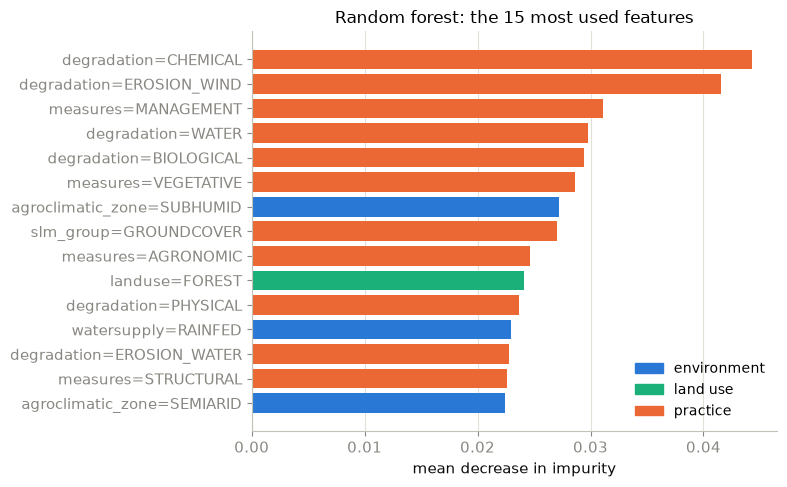

top feature: 4.4% of the total importance; top 15 together: 42%

                                  block  prevalence  share high | present  share high | absent  difference
degradation=CHEMICAL           practice       0.434                 0.389                0.232       0.157
degradation=EROSION_WIND       practice       0.284                 0.426                0.251       0.176
measures=MANAGEMENT            practice       0.530                 0.354                0.240       0.114
degradation=WATER              practice       0.340                 0.387                0.256       0.130
degradation=BIOLOGICAL         practice       0.695                 0.345                0.199       0.147
measures=VEGETATIVE            practice       0.603                 0.346                0.232       0.114
agroclimatic_zone=SUBHUMID  environment       0.392                 0.229                0.347      -0.118
slm_group=GROUNDCOVER          practice       0.351                 0.345      

In [6]:
forest = make_forest().fit(X, y)
imp = pd.Series(forest.feature_importances_, index=X_df.columns).sort_values(ascending=False).head(15)
present = {f: (X_df[f] == 1).to_numpy() for f in imp.index}
direction = pd.DataFrame({"block": [BLOCK_OF[FIELD_OF[f]] for f in imp.index],
                          "prevalence": [present[f].mean() for f in imp.index],
                          "share high | present": [y[present[f]].mean() for f in imp.index],
                          "share high | absent": [y[~present[f]].mean() for f in imp.index]}, index=imp.index)
direction["difference"] = direction["share high | present"] - direction["share high | absent"]

fig, ax = plt.subplots(figsize=(8, 5))
colours = {"environment": C_BLUE, "land use": C_AQUA, "practice": C_ORANGE}
ax.barh(imp.index[::-1], imp.values[::-1], color=[colours[BLOCK_OF[FIELD_OF[c]]] for c in imp.index[::-1]])
ax.legend(handles=[Patch(color=v, label=k) for k, v in colours.items()], loc="lower right")
ax.set_xlabel("mean decrease in impurity"); ax.set_title("Random forest: the 15 most used features"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(f"top feature: {imp.iloc[0] / forest.feature_importances_.sum():.1%} of the total importance; top 15 together: {imp.sum() / forest.feature_importances_.sum():.0%}\n")
print(direction.round(3).to_string())

In [7]:
ticked = pd.DataFrame({f: tokens(data[f]).apply(lambda t: 0 if t == ["MISSING"] else len(t)) for f in PRACTICE})
by_count = {}
for f in PRACTICE:
    k = ticked[f].where(ticked[f] > 0).clip(upper=5)
    by_count[f] = pd.Series(y).groupby(k).agg(lambda s: f"{s.mean():.2f} ({len(s)})").reindex([1, 2, 3, 4, 5])
by_count = pd.DataFrame(by_count).T.set_axis(["1", "2", "3", "4", "5+"], axis=1)
print("share of 'high' by the number of answers ticked in each multi-answer practice field (records in brackets):")
print(by_count.to_string())
print()
print("Spearman correlation of the count with the label:", ", ".join(f"{f} {pd.Series(y).corr(ticked[f], method='spearman'):+.2f}" for f in PRACTICE))

share of 'high' by the number of answers ticked in each multi-answer practice field (records in brackets):
                       1           2           3          4          5+
slm_group     0.24 (131)  0.35 (145)  0.28 (174)   0.50 (6)         NaN
measures      0.20 (166)  0.35 (161)  0.30 (100)  0.47 (47)    0.67 (3)
degradation   0.17 (100)  0.23 (119)  0.36 (122)  0.38 (88)   0.47 (49)
main_purpose   0.42 (81)   0.32 (77)   0.18 (55)  0.34 (53)  0.27 (157)

Spearman correlation of the count with the label: slm_group +0.01, measures +0.16, degradation +0.21, main_purpose -0.03


**Reading the forest.** The importance profile is flat: the top feature holds 4.4 % of the total,
the top 15 together 42 %. Almost the whole top of the list is the *practice* block, and within it
the land-degradation types a technology addresses: technologies addressing wind erosion report the
top biomass score 43 % of the time against 25 % for the rest (+18 points); chemical (+16),
biological (+15) and water degradation (+13) follow. Management and vegetative measures add +11
points each. The environment enters through dryness: sub-humid sites report fewer top scores
(−12 points), semi-arid sites more (+7), rainfed sites fewer (−7). Water erosion is the one practice
feature pointing down (−6).

**The count matters more than the type.** When nearly every degradation type points upward, the
number of types ticked is the obvious suspect, and the table confirms it: 17 % of the technologies
addressing one degradation type report a +3, 47 % of those addressing five or more (Spearman
+0.21); for measures the share rises from 20 % (one) to 47 % (four). The number of SLM groups or
main purposes shows no such trend. A technology that tackles many problems at once may really build
more biomass, but the count is also a trace of how thoroughly — and how enthusiastically — the
compiler filled in the form: Dima's rater warning in another guise. Impurity importance is unsigned
and favours frequent features (agronomic measures are in the top 15 with a difference of just +2
points), which is why section 7.5 uses permutation importance instead.

## 5. Method 1 — a regularised deep feed-forward network

A multilayer perceptron on the 82 one-hot features, built with the Module 2 training toolbox:

| technique | what it does here |
|---|---|
| He initialisation | keeps activations at a sane scale through the layers |
| ReLU | non-saturating, no vanishing gradient |
| Batch normalisation | normalises inside the network, allows a larger learning rate (`use_bias=False` before it) |
| Dropout + L2 | the two regularisers that matter most with 480 rows |
| Adam | adaptive per-weight learning rates |
| `ReduceLROnPlateau` | halves the learning rate when the validation loss stalls |
| Early stopping | stops when the validation loss stops improving, restores the best weights |

We first show the failure mode without regularisation, then the regularised network, then tune it.
Every cross-validated network result is a mean over **5 folds × 3 seeds** (`run_keras_seeds`): with
about 380 training rows, the random seed alone moves a network's AUC by several hundredths.

In [8]:
def dense_trunk(h, hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", name="trunk"):
    reg = keras.regularizers.l2(l2) if l2 else None
    for i, units in enumerate(hidden):
        h = layers.Dense(units, kernel_initializer="he_normal", use_bias=not batchnorm, kernel_regularizer=reg)(h)
        if batchnorm:
            h = layers.BatchNormalization()(h)
        h = layers.Activation(activation, name=f"{name}_out" if i == len(hidden) - 1 else None)(h)
        if dropout:
            h = layers.Dropout(dropout)(h)
    return h

def build_mlp(hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", lr=1e-3):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    out = layers.Dense(1, activation="sigmoid", name="bio_high")(dense_trunk(inp, hidden, dropout, l2, batchnorm, activation))
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
    return model

def callbacks(patience=15):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

def run_keras_cv(build, Xany, extra_targets=None, name=None, epochs=150, batch_size=32, seed=SEED):
    """Grouped 5-fold CV for a Keras model whose (first) output is the bio_high sigmoid.
    build(train_idx) returns a compiled model. Returns (fold scores, fitted models, histories)."""
    t0, out, models, histories = time.time(), [], [], []
    for k, (tr, te) in enumerate(FOLDS):
        keras.utils.clear_session(); keras.utils.set_random_seed(seed + k)
        tr_in, va_in = inner_split(tr, seed + k)
        target = (lambda idx: y[idx]) if extra_targets is None else (lambda idx: {"bio_high": y[idx], **{n: t[idx] for n, t in extra_targets.items()}})
        model = build(tr_in)
        h = model.fit(Xany[tr_in], target(tr_in), validation_data=(Xany[va_in], target(va_in)),
                      epochs=epochs, batch_size=batch_size, callbacks=callbacks(), verbose=0)
        pred = model.predict(Xany[te], verbose=0)
        p = (pred["bio_high"] if isinstance(pred, dict) else pred).ravel()
        out.append(scores_from(y[te], p, y[tr].mean())); models.append(model); histories.append(h.history)
    if name:
        record(name, out, time.time() - t0)
    return out, models, histories

SEEDS = (SEED, 7, 123)
def run_keras_seeds(build, Xany, extra_targets=None, name=None):
    """run_keras_cv once per seed. On ~380 training rows the seed alone moves a network's AUC by several
    hundredths, so every network result below is a mean over 5 folds x 3 seeds. Models come back seed by seed,
    fold by fold: models[i] was tested on (FOLDS * len(SEEDS))[i]."""
    t0, out, models = time.time(), [], []
    for s in SEEDS:
        fold_scores, fold_models, _ = run_keras_cv(build, Xany, extra_targets, seed=s)
        out += fold_scores; models += fold_models
    if name:
        record(name, out, time.time() - t0)
    return out, models

build_mlp().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ onehot (InputLayer)             │ (None, 82)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trunk_out (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bio_high (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 384 (1.50 KB)

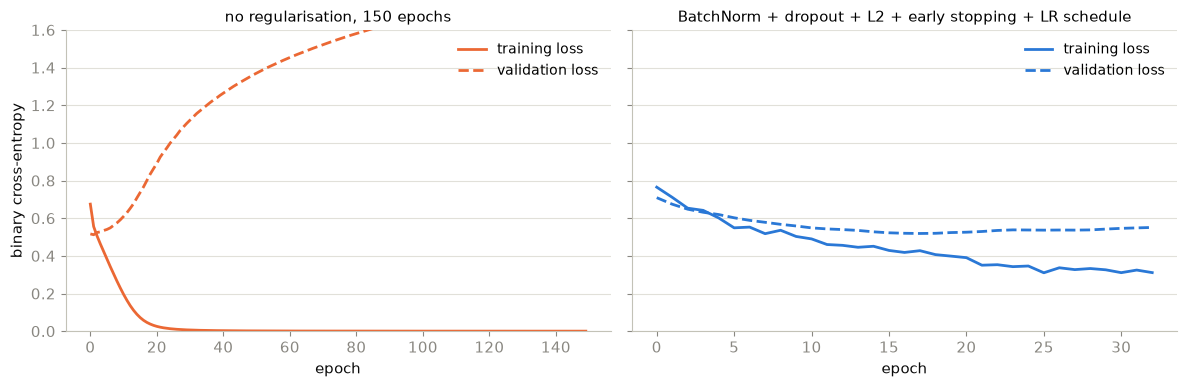

fold-0 test AUC: naive 0.638 (150 epochs)  |  regularised 0.615 (stopped after 33 epochs)


In [9]:
tr0, te0 = FOLDS[0]; tr_in0, va_in0 = inner_split(tr0)
keras.utils.set_random_seed(SEED)
naive = build_mlp(hidden=(256, 128), dropout=0.0, l2=0.0, batchnorm=False)
h_naive = naive.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, verbose=0)
keras.utils.set_random_seed(SEED)
regular = build_mlp()
h_reg = regular.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, callbacks=callbacks(), verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, hist, title, colour in [(axes[0], h_naive.history, "no regularisation, 150 epochs", C_ORANGE),
                                (axes[1], h_reg.history, "BatchNorm + dropout + L2 + early stopping + LR schedule", C_BLUE)]:
    ax.plot(hist["loss"], color=colour, linewidth=2, label="training loss")
    ax.plot(hist["val_loss"], color=colour, linewidth=2, linestyle="--", label="validation loss")
    ax.set_title(title, fontsize=11); ax.set_xlabel("epoch"); ax.legend(); tidy(ax)
axes[0].set_ylabel("binary cross-entropy"); axes[0].set_ylim(0, 1.6)
plt.tight_layout(); plt.show()
print(f"fold-0 test AUC: naive {roc_auc_score(y[te0], naive.predict(X[te0], verbose=0).ravel()):.3f} (150 epochs)  |  "
      f"regularised {roc_auc_score(y[te0], regular.predict(X[te0], verbose=0).ravel()):.3f} (stopped after {len(h_reg.history['loss'])} epochs)")

Left: the network memorises its ~320 training rows — training loss to zero, validation loss rising
almost from the start. Right: with the toolbox the validation loss falls a little, flattens, and
early stopping ends training after about thirty epochs. (The single-fold test AUCs printed above are
one fold of 99 records and one seed. That the naive network happens to score higher there is exactly
the kind of noise the next cell averages away; the curves are the point.)

**Tuning.** Four configurations along the two axes that matter most on small data, width and
dropout, each evaluated on the same grouped folds with three seeds. (Picking the best of four on the
folds we report is slightly optimistic; nested cross-validation would remove that, at four
candidates the effect is a fraction of an AUC point.)

In [10]:
SWEEP = {"narrow (64), no dropout": dict(hidden=(64,), dropout=0.0, l2=0.0),
         "narrow (64), dropout 0.3": dict(hidden=(64,), dropout=0.3, l2=1e-4),
         "wide (256-128), no dropout": dict(hidden=(256, 128), dropout=0.0, l2=0.0),
         "wide (256-128), dropout 0.5": dict(hidden=(256, 128), dropout=0.5, l2=1e-4)}
sweep, best = [], None
for label, cfg in SWEEP.items():
    t0 = time.time()
    fold_scores, _ = run_keras_seeds(lambda idx: build_mlp(**cfg), X)
    df = pd.DataFrame(fold_scores).assign(seed=np.repeat(SEEDS, len(FOLDS)))
    per_seed = df.groupby("seed", sort=False)["AUC"].mean()
    sweep.append({"config": label, "AUC": df["AUC"].mean(), **{f"AUC seed {s}": per_seed[s] for s in SEEDS},
                  "macro-F1": df["macro-F1"].mean(), "seconds": time.time() - t0})
    if best is None or df["AUC"].mean() > best[1]:
        best = (label, df["AUC"].mean(), fold_scores, time.time() - t0)
print(pd.DataFrame(sweep).set_index("config").round(3).to_string())
record(f"1. Feed-forward net ({best[0]})", best[2], best[3])

                               AUC  AUC seed 42  AUC seed 7  AUC seed 123  macro-F1  seconds
config                                                                                      
narrow (64), no dropout      0.576        0.576       0.557         0.596     0.449   83.872
narrow (64), dropout 0.3     0.582        0.578       0.565         0.605     0.466   92.116
wide (256-128), no dropout   0.589        0.619       0.542         0.604     0.457   84.633
wide (256-128), dropout 0.5  0.580        0.596       0.570         0.575     0.444  104.407
1. Feed-forward net (wide (256-128), no dropout) AUC 0.589 ± 0.056   macro-F1 0.457 ± 0.106   (  85 s)


All four configurations land between AUC 0.576 and 0.589, while the seeds within one configuration
differ by up to 0.08: the selected one, wide without dropout, scores 0.619 with seed 42 and 0.542
with seed 7. The grid cannot separate the configurations, and a single-seed grid would simply have
crowned the luckiest seed. What the regularisation toolbox buys on this data is training that is
stable and stops by itself, not a higher score. The selected network reaches AUC 0.589 — below
logistic regression (0.629) and the random forest (0.626). On 480 rows of one-hot answers, hidden
layers find no interactions worth their extra variance, and the yardsticks make that visible.

## 6. Method 2 — a multi-task network for all eight biodiversity indicators

`research.md` names biomass as the main output and the other indicators of section 6.1 as optional
outputs, and section 2 showed they are correlated but not identical. So the network gets **two
heads on one shared trunk**:

* `bio_high` — the same biomass high/low sigmoid classifier as method 1 (binary cross-entropy);
* `indicators` — eight linear outputs, one per indicator (biomass included), trained with a **masked
  mean squared error** that ignores the indicators a compiler did not score (the mask zeroes the
  error where the label is `NaN` and divides by the number of labels present).

The total loss is the weighted sum (weight 0.5 on the indicator head). The trunk has to serve nine
targets at once, which regularises it, and the indicator head gives a prediction per indicator for
every technology — the basis of the heat-map in section 7.4. The trunk is method 1's default
(128-64, dropout 0.3), not the grid's pick: section 5 showed the grid cannot tell the
configurations apart.

**One detail we got wrong first.** With the indicator head's bias initialised at zero, early
stopping (which watches the *combined* validation loss, dominated by the classification head)
stopped after ~5 epochs, before the regression head had even learned the indicator means of
1.5–1.9. The per-indicator skill came out at −0.3 to −0.5, a training artefact. Initialising the
bias at the training means (`bias_initializer=Constant(...)`) removes it.

In [11]:
def masked_mse(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.square(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def masked_mae(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.abs(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def build_multitask(indicator_bias=None, hidden=(128, 64), dropout=0.3, l2=1e-4, lr=1e-3, indicator_weight=0.5):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    h = dense_trunk(inp, hidden, dropout, l2)
    out_high = layers.Dense(1, activation="sigmoid", name="bio_high")(h)
    bias_init = keras.initializers.Constant(indicator_bias) if indicator_bias is not None else "zeros"
    out_ind = layers.Dense(len(BIO), name="indicators", bias_initializer=bias_init)(h)
    model = keras.Model(inp, {"bio_high": out_high, "indicators": out_ind})
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss={"bio_high": "binary_crossentropy", "indicators": masked_mse},
                  loss_weights={"bio_high": 1.0, "indicators": indicator_weight},
                  metrics={"bio_high": [keras.metrics.AUC(name="auc")], "indicators": [masked_mae]})
    return model

scores_C, models_C = run_keras_seeds(lambda idx: build_multitask(indicator_bias=np.nanmean(Y_IND[idx], axis=0)),
                                     X, extra_targets={"indicators": Y_IND}, name="2. Multi-task net (8 indicators + high/low)")

2. Multi-task net (8 indicators + high/low) AUC 0.598 ± 0.074   macro-F1 0.464 ± 0.071   ( 133 s)


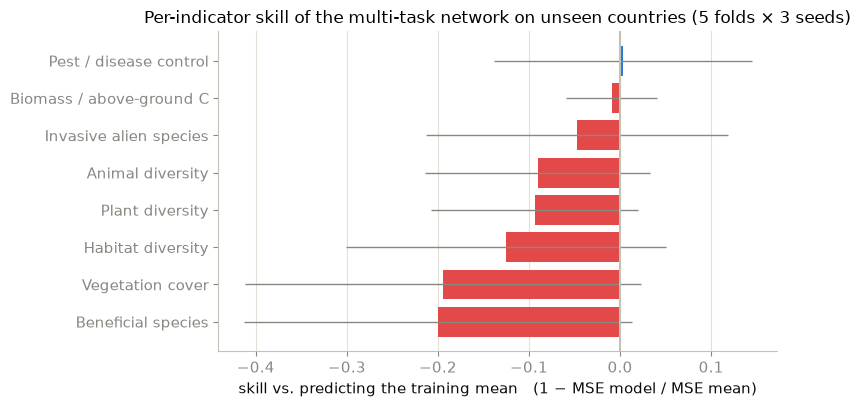

                             n  skill     sd
indicator                                   
Beneficial species         525 -0.200  0.213
Vegetation cover           600 -0.195  0.217
Habitat diversity          624 -0.125  0.176
Plant diversity            873 -0.094  0.114
Animal diversity           471 -0.091  0.123
Invasive alien species     174 -0.047  0.166
Biomass / above-ground C  1437 -0.009  0.050
Pest / disease control     396  0.003  0.142


In [12]:
rows = []
for model, (tr, te) in zip(models_C, FOLDS * len(SEEDS)):
    pred = model.predict(X[te], verbose=0)["indicators"]
    for j, b in enumerate(BIO):
        m = ~np.isnan(Y_IND[te, j])
        if m.sum() < 5:
            continue
        mse_model = np.mean((Y_IND[te, j][m] - pred[m, j]) ** 2)
        mse_mean = np.mean((Y_IND[te, j][m] - np.nanmean(Y_IND[tr, j])) ** 2)
        rows.append({"indicator": PRETTY[b], "n": int(m.sum()), "skill": 1 - mse_model / mse_mean})
skill = pd.DataFrame(rows).groupby("indicator").agg(n=("n", "sum"), skill=("skill", "mean"), sd=("skill", "std")).sort_values("skill")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(skill.index, skill["skill"], xerr=skill["sd"], color=[C_BLUE if s >= 0 else C_RED for s in skill["skill"]], error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("skill vs. predicting the training mean   (1 − MSE model / MSE mean)")
ax.set_title("Per-indicator skill of the multi-task network on unseen countries (5 folds × 3 seeds)"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(skill.round(3).to_string())

**Reading the skill plot.** Every bar sits between −0.2 and 0: on unseen countries the network
predicts each biodiversity number *no better than that indicator's training mean* — biomass
included (−0.01), even though the classification head finds some signal in the same data (an AUC
of 0.60 corresponds to a very small share of explained variance). The questionnaire fields do not
carry the information, not even for the strongly inter-correlated vegetation cluster. This is a
result, not a failure of the method: it is the per-indicator version of Dima's warning, and it tells
us to read the heat-map in 7.4 as the model's *tendencies*, not as predictions. On the shared
`bio_high` head the multi-task network is level with method 1: AUC 0.598 against 0.589, a difference
far inside the seed-to-seed spread.

## 7. Results: which methods go with the largest reported biomass gains?

### 7.1 All models on the same folds

                                                    AUC  AUC sd  macro-F1  macro-F1 sd  balanced acc.  seconds
approach                                                                                                      
0a. Majority class                                0.500   0.000     0.412        0.007          0.500    0.019
0b. Logistic regression                           0.629   0.035     0.614        0.031          0.636    0.076
0c. Random forest                                 0.626   0.028     0.562        0.026          0.591    6.165
1. Feed-forward net (wide (256-128), no dropout)  0.589   0.056     0.457        0.106          0.552   84.633
2. Multi-task net (8 indicators + high/low)       0.598   0.074     0.464        0.071          0.556  132.885


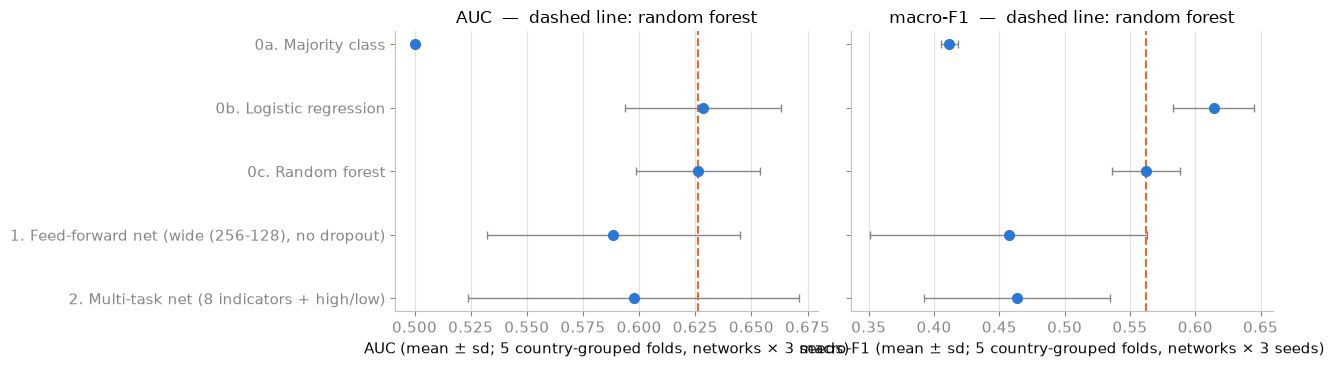

In [13]:
table = summary_table()
print(table.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
names = list(table.index)
for ax, metric in zip(axes, ["AUC", "macro-F1"]):
    ax.errorbar(table[metric], range(len(names)), xerr=table[f"{metric} sd"], fmt="o", color=C_BLUE, ecolor=INK_MUTED, elinewidth=1, capsize=3, markersize=7)
    ax.axvline(table.loc["0c. Random forest", metric], color=C_ORANGE, linestyle="--", linewidth=1.5)
    ax.set_xlabel(f"{metric} (mean ± sd; 5 country-grouped folds, networks × 3 seeds)"); ax.set_title(f"{metric}  —  dashed line: random forest"); tidy(ax, "x")
axes[0].set_yticks(range(len(names)), names); axes[0].invert_yaxis()
plt.tight_layout(); plt.show()

The classical yardsticks lead, and logistic regression — the model without hidden layers — is the
best of all (AUC 0.629, macro-F1 0.61, balanced accuracy 0.64). Both networks sit 0.03–0.04 AUC
below with twice the spread. Their macro-F1 suffers most because their probabilities are not
calibrated (the multi-task ensemble predicts P(high) = 0.37 on average for a class that makes up
0.30, section 7.3), so the training-share threshold misplaces many records. Every model is clearly
above chance, but not by much: AUC 0.63 means that of a random pair of one +3 record and one lower
record, the model ranks the +3 higher 63 % of the time.

### 7.2 Sensitivity: does following `research.md` matter?

The two yardsticks on five variants of the problem: the biomass target split both ways, biomass with
the ten extra fields, and the mean of all eight indicators (the target of the earlier version of
this notebook, 895 records) with both feature sets. Each variant gets its own stratified,
country-grouped folds; the first row is the main analysis and repeats 0b and 0c.

In [14]:
EXTRA = ["rainfall", "altitude", "landform", "soil_depth", "soil_texture", "topsoil_organic",   # fields research.md does not list
         "market_orientation", "mechanisation", "land_size", "wealth"]
X_research = encode_onehot(wocat)
X_extended = encode_onehot(wocat, SINGLE + EXTRA, MULTI)
biomass, mean8 = bio_all[TARGET], bio_all["bio_mean"]
VARIANTS = [  # (target, split, features, label, rows)
    ("biomass", "> median (+3 vs rest)", "research.md", biomass > MEDIAN, biomass.notna()),
    ("biomass", ">= median (+2, +3 vs rest)", "research.md", biomass >= MEDIAN, biomass.notna()),
    ("biomass", "> median (+3 vs rest)", "research.md + 10 extra", biomass > MEDIAN, biomass.notna()),
    ("8-indicator mean", "> its median", "research.md", mean8 > mean8.median(), mean8.notna()),
    ("8-indicator mean", "> its median", "research.md + 10 extra", mean8 > mean8.median(), mean8.notna()),
]
rows = []
for target, split, feats, label, keep in VARIANTS:
    ids = bio_all.loc[keep, "technology_id"]
    Xv = (X_research if feats == "research.md" else X_extended).loc[ids].to_numpy(dtype=np.float32)
    yv, gv = label[keep].astype(int).to_numpy(), bio_all.loc[keep, "country_name"].to_numpy()
    folds_v = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(Xv, yv, gv))
    row = {"target": target, "split": split, "features": f"{feats} ({Xv.shape[1]})", "records": len(yv), "share high": yv.mean()}
    for short, make in [("logistic reg.", make_logreg), ("random forest", make_forest)]:
        auc = pd.DataFrame(cv_sklearn(make, Xv, yv, folds_v))["AUC"]
        row[f"{short} AUC"], row[f"{short} sd"] = auc.mean(), auc.std()
    rows.append(row)
sensitivity = pd.DataFrame(rows)
print(sensitivity.round(3).to_string(index=False))

          target                      split                     features  records  share high  logistic reg. AUC  logistic reg. sd  random forest AUC  random forest sd
         biomass      > median (+3 vs rest)             research.md (82)      479       0.301              0.629             0.035              0.626             0.028
         biomass >= median (+2, +3 vs rest)             research.md (82)      479       0.681              0.557             0.049              0.557             0.040
         biomass      > median (+3 vs rest) research.md + 10 extra (148)      479       0.301              0.582             0.028              0.590             0.024
8-indicator mean               > its median             research.md (82)      895       0.489              0.555             0.030              0.581             0.039
8-indicator mean               > its median research.md + 10 extra (148)      895       0.489              0.515             0.034              0.559           

Three things follow.

* **Biomass is the more predictable target.** With the same fields it reaches AUC 0.63 against
  0.56–0.58 for the 8-indicator mean, on half the records. Averaging eight indicators mixes scores
  the form asks about for very different reasons (pest control, invasive species) and dilutes the
  one WOCAT cares about most.
* **The ten extra fields hurt.** They cost logistic regression 0.04–0.05 and the random forest
  0.02–0.04 on both targets: more one-hot columns for the same number of rows, more room to fit
  noise.
* **The split matters.** Moving the cut one step down (+2 and +3 against +1 or less, 68 / 32) drops
  the AUC to 0.56: the fields separate the top rating from the rest better than modest from good
  ratings. We chose the strict split because it is `research.md`'s rule applied literally and the
  convention of the earlier version, but it is also the easier one, which is why the other split is
  reported here.

### 7.3 Raw ranking vs. environment-adjusted what-if

The raw ranking mixes what a method does with *where* it is used (forest technologies sit in humid
zones, water harvesting in arid ones). The multi-task network lets us separate the two with a
counterfactual: *if every one of the 479 technologies had used method g — in its own climate, slope,
water supply and land use — what would the network expect?* We switch every technology's SLM-group
indicator to *only* g, leave everything else untouched, predict with all 15 multi-task models
(5 folds × 3 seeds) and average. Grey = raw share of +3 biomass scores among technologies listing
the group; blue = the what-if probability.

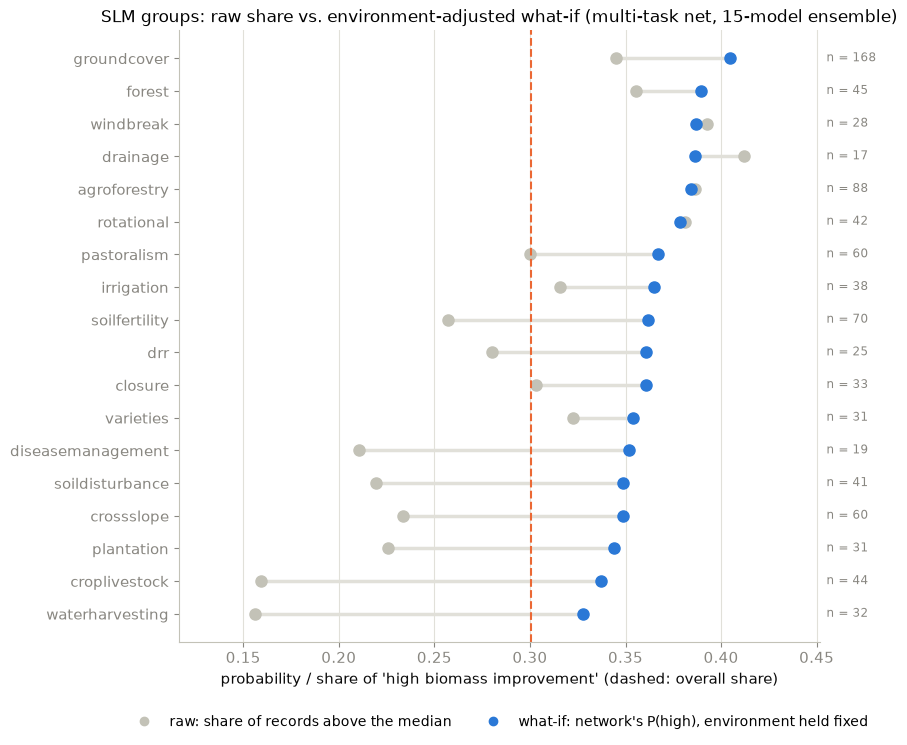

ensemble mean P(high) on the records as they are: 0.373; share of high records: 0.301

                     n  raw share high  adjusted P(high)
GROUNDCOVER        168           0.345             0.404
FOREST              45           0.356             0.390
WINDBREAK           28           0.393             0.387
DRAINAGE            17           0.412             0.387
AGROFORESTRY        88           0.386             0.384
ROTATIONAL          42           0.381             0.378
PASTORALISM         60           0.300             0.367
IRRIGATION          38           0.316             0.365
SOILFERTILITY       70           0.257             0.362
CLOSURE             33           0.303             0.361
DRR                 25           0.280             0.361
VARIETIES           31           0.323             0.354
DISEASEMANAGEMENT   19           0.211             0.352
CROSSSLOPE          60           0.233             0.349
SOILDISTURBANCE     41           0.220             0.349
P

In [15]:
long = data[["bio_high", TARGET]].assign(group=tokens(data["slm_group"])).explode("group")
share_high = long.groupby("group")["bio_high"].mean()
n_group = long.groupby("group").size()
GROUPS_SHOWN = [g for g in n_group.index if n_group[g] >= 15 and g not in ("MISSING", "OTHER")]
SLM_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("slm_group=")}

def what_if(models, category):
    Xc = X.copy(); Xc[:, list(SLM_COL.values())] = 0.0; Xc[:, SLM_COL[category]] = 1.0
    preds = [m.predict(Xc, verbose=0) for m in models]
    return (np.mean([p["bio_high"].ravel() for p in preds], axis=0).mean(),
            np.mean([p["indicators"] for p in preds], axis=0).mean(axis=0))

adjusted = {}
for g in GROUPS_SHOWN:
    p, ind = what_if(models_C, g)
    adjusted[g] = {"adjusted P(high)": p, **{b: v for b, v in zip(BIO, ind)}}
adjusted = pd.DataFrame(adjusted).T.astype(float)
adjusted["raw share high"] = share_high.reindex(adjusted.index); adjusted["n"] = n_group.reindex(adjusted.index)
adjusted = adjusted.sort_values("adjusted P(high)")

fig, ax = plt.subplots(figsize=(9, 0.32 * len(adjusted) + 1.8))
for i, (g, r) in enumerate(adjusted.iterrows()):
    ax.plot([r["raw share high"], r["adjusted P(high)"]], [i, i], color=GRID, linewidth=2.5, zorder=1)
    ax.plot(r["raw share high"], i, "o", color=NEUTRAL, markersize=8, zorder=2)
    ax.plot(r["adjusted P(high)"], i, "o", color=C_BLUE, markersize=8, zorder=3)
    ax.text(1.01, i, f"n = {int(r['n'])}", va="center", fontsize=8.5, color=INK_MUTED, transform=ax.get_yaxis_transform())
ax.plot([], [], "o", color=NEUTRAL, label="raw: share of records above the median")
ax.plot([], [], "o", color=C_BLUE, label="what-if: network's P(high), environment held fixed")
ax.axvline(y.mean(), color=C_ORANGE, linestyle="--", linewidth=1.5)
values = adjusted[["raw share high", "adjusted P(high)"]].to_numpy()
ax.set_yticks(range(len(adjusted)), [g.lower() for g in adjusted.index]); ax.set_xlim(values.min() - 0.04, values.max() + 0.04)
ax.set_xlabel("probability / share of 'high biomass improvement' (dashed: overall share)")
ax.set_title("SLM groups: raw share vs. environment-adjusted what-if (multi-task net, 15-model ensemble)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(f"ensemble mean P(high) on the records as they are: {np.mean([m.predict(X, verbose=0)['bio_high'].ravel() for m in models_C]):.3f}; share of high records: {y.mean():.3f}\n")
print(adjusted[["n", "raw share high", "adjusted P(high)"]].round(3).sort_values("adjusted P(high)", ascending=False).to_string())

### 7.4 Which method helps which biodiversity number?

Two heat-maps with the same layout — rows are SLM groups in the what-if order, columns the eight
indicators, colour is the cell minus its column mean (blue = better than the typical method for
that indicator, red = worse). The first is purely descriptive (mean reported score of the biomass
records listing the group; blank where fewer than 8 scores). The second is the model's what-if.
Where both agree we have something to say; where only the raw map is coloured, we are looking at a
handful of records.

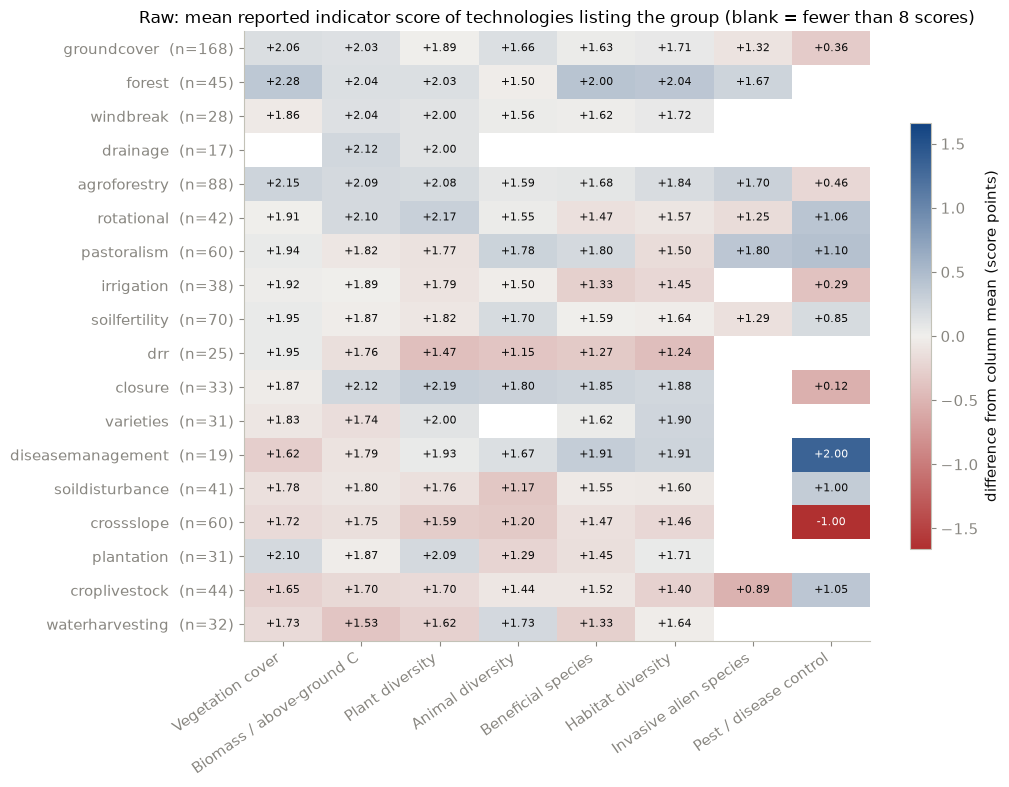

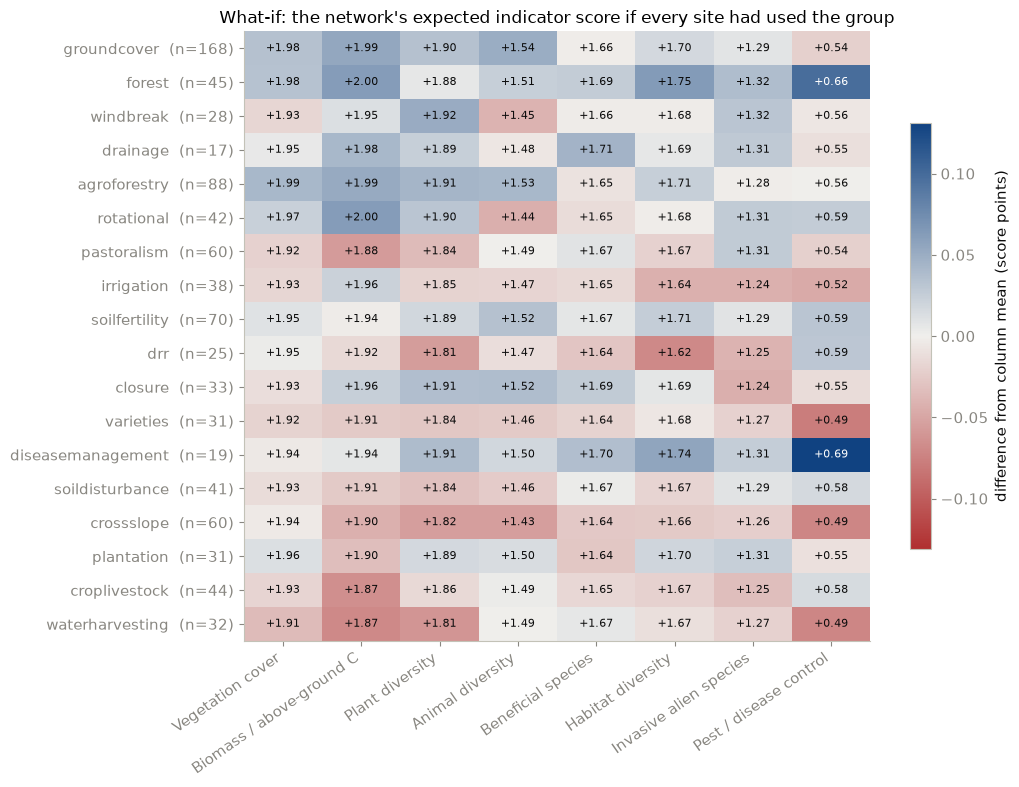

rank agreement raw vs what-if, per indicator (Spearman):
Vegetation cover            0.65
Biomass / above-ground C    0.85
Plant diversity             0.73
Animal diversity            0.50
Beneficial species          0.71
Habitat diversity           0.82
Invasive alien species      0.25
Pest / disease control      0.65


In [16]:
order = adjusted.sort_values("adjusted P(high)", ascending=False).index
long_ind = data[["technology_id"] + BIO].assign(group=tokens(data["slm_group"])).explode("group")
raw_agg = long_ind[long_ind["group"].isin(GROUPS_SHOWN)].groupby("group")[BIO].agg(["mean", "count"])
raw_mean = raw_agg.xs("mean", axis=1, level=1).reindex(columns=BIO).where(raw_agg.xs("count", axis=1, level=1).reindex(columns=BIO) >= 8).loc[order]

def plot_heat(values, title):
    centred = values - values.mean(axis=0); lim = float(np.nanmax(np.abs(centred.values)))
    fig, ax = plt.subplots(figsize=(10.5, 8))
    im = ax.imshow(np.ma.masked_invalid(centred.values), cmap=BLUE_RED.reversed(), vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(8), [PRETTY[b] for b in BIO], rotation=35, ha="right")
    ax.set_yticks(range(len(values)), [f"{g.lower()}  (n={int(adjusted.loc[g, 'n'])})" for g in values.index])
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8, color="white" if abs(centred.values[i, j]) > 0.6 * lim else INK)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.7, label="difference from column mean (score points)"); tidy(ax, None)
    plt.tight_layout(); plt.show()

plot_heat(raw_mean, "Raw: mean reported indicator score of technologies listing the group (blank = fewer than 8 scores)")
plot_heat(adjusted[BIO].loc[order], "What-if: the network's expected indicator score if every site had used the group")
agreement = pd.Series({PRETTY[b]: raw_mean[b].corr(adjusted[b].loc[order], method="spearman") for b in BIO}).round(2)
print("rank agreement raw vs what-if, per indicator (Spearman):"); print(agreement.to_string())

### 7.5 Which feature blocks does the network actually use?

Permutation importance on the test folds: shuffle one block of columns at a time (all columns of
the block together, so multi-hot rows stay valid) and measure the AUC each of the 15 multi-task
models loses on its own test fold.

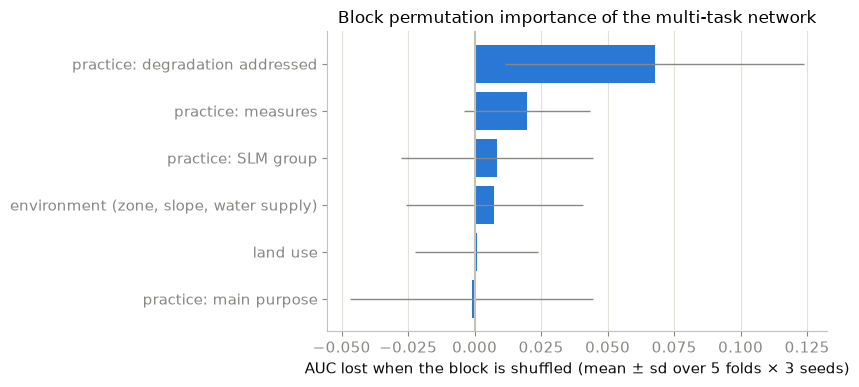

                                          mean    std
block                                                
practice: main purpose                  -0.001  0.046
land use                                 0.001  0.023
environment (zone, slope, water supply)  0.007  0.033
practice: SLM group                      0.008  0.036
practice: measures                       0.020  0.024
practice: degradation addressed          0.068  0.056


In [17]:
BLOCKS = {"environment (zone, slope, water supply)": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in ENVIRONMENT],
          "land use": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in LAND_USE],
          "practice: SLM group": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "slm_group"],
          "practice: measures": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "measures"],
          "practice: degradation addressed": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "degradation"],
          "practice: main purpose": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "main_purpose"]}
rng = np.random.default_rng(SEED); rows = []
for model, (tr, te) in zip(models_C, FOLDS * len(SEEDS)):
    base = roc_auc_score(y[te], model.predict(X[te], verbose=0)["bio_high"].ravel())
    for name, cols in BLOCKS.items():
        drops = []
        for _ in range(5):
            Xp = X[te].copy(); Xp[:, cols] = Xp[rng.permutation(len(te))][:, cols]
            drops.append(base - roc_auc_score(y[te], model.predict(Xp, verbose=0)["bio_high"].ravel()))
        rows.append({"block": name, "AUC drop": np.mean(drops)})
block_imp = pd.DataFrame(rows).groupby("block")["AUC drop"].agg(["mean", "std"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(block_imp.index, block_imp["mean"], xerr=block_imp["std"], color=C_BLUE, error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("AUC lost when the block is shuffled (mean ± sd over 5 folds × 3 seeds)")
ax.set_title("Block permutation importance of the multi-task network"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(block_imp.round(3).to_string())

### 7.6 Synthesis

* **Ground cover, forest, windbreak, agroforestry and rotational systems form the top group**: raw
  shares of 0.35–0.39 and what-if probabilities of 0.38–0.40. Drainage is up there too, but on 17
  records.
* **Water harvesting and crop–livestock integration trail in every view** (raw shares 0.16, last
  in the what-if), with plantation, soil-disturbance and cross-slope practices just above them. For
  crop–livestock integration this reverses the earlier version of this notebook, where the
  8-indicator mean over 895 records put it second; among the 44 technologies that do score biomass
  it rarely gets the top rating (mean +1.70, against +2.04 for forest and +2.09 for agroforestry).
  **The choice of target changes the answer**, which is the strongest argument for following
  `research.md`.
* **Holding the environment fixed changes the order only a little.** Ground cover (6th → 1st) and
  forest (5th → 2nd) gain, drainage (1st → 4th) and crop varieties (7th → 12th) lose, the bottom two
  stay. The what-if compresses the range from 0.16–0.41 to 0.33–0.40: the network barely uses the
  SLM group (7.5), so switching it cannot move a probability far, and the level is off (mean
  P(high) 0.37 for a class share of 0.30). Read the order and the gaps, not the height of the blue
  dots.
* **Raw and what-if agree best for biomass itself** (Spearman 0.85) and habitat diversity (0.82),
  worst for invasive species (0.25, 58 records). In the pest / disease control column, disease
  management stands out in both maps, the one cell where method and indicator obviously belong
  together.
* **What the network uses is the degradation block, and mostly its size.** Shuffling the degradation
  types addressed costs the multi-task network 0.07 AUC (± 0.06), the measures 0.02; SLM group,
  environment, land use and main purpose cost nothing measurable. Together with section 4, where the
  share of +3 scores rises from 17 % to 47 % with the number of degradation types ticked, this says
  the strongest predictor is how comprehensively a technology is described, not which method it is.

## 8. Conclusions and limitations

**Answer to the research question.** Following `research.md` — biomass / above-ground C as the
output, split at the median, and its input fields — the WOCAT questionnaire predicts a technology's
*reported* biomass gain modestly: AUC 0.63 on unseen countries for logistic regression and the random
forest, 0.59–0.60 for the neural networks. That is clearly better than the mean of all eight
biodiversity indicators with a broader feature set (0.52–0.56), and the individual indicators are
not predictable beyond their means. The methods associated with the highest reported biomass gains
are ground cover, forest, windbreak and agroforestry; water harvesting and crop–livestock
integration trail, and that order survives holding the environment fixed. The strongest single
predictor is how many degradation types a technology addresses, which says as much about how the
forms are filled in as about the land.

**What the numbers cannot say.** Every score is one person's opinion of their own project, there
are no failures and no control plots, and compilers who documented many technologies rate
systematically higher or lower. The what-if is the network's belief about *reported* impact in a
counterfactual it never observed. It describes what the WOCAT community reports, not what works.
And this is not yet the full `research.md` model: four of its seven essential inputs (groundwater
table, surface water, establishment and maintenance cost) are missing from the cached data.

**Module 2 methods used.** A deep feed-forward network designed, trained, tuned and regularised
with the D1 toolbox (method 1); a multi-output network built with the functional API and a custom
masked loss (method 2, an extension of the course's multi-output and custom-loss examples); grouped
cross-validation repeated over three seeds, and permutation importance, for honest evaluation.

**What else we tried, and set aside.** *Entity embeddings* (a learned vector per questionnaire
category, functional API with one input per field) and *transfer learning* from the other impact
blocks (pre-train a trunk on soil, water, production, … scores; freeze; fine-tune) were tried on the
earlier target, the 8-indicator mean: AUC 0.51 and 0.53–0.54, no better than training from scratch,
and not repeated for biomass. *Class weights* would handle the 30 / 70 split as well as the
training-share threshold does, but they distort the probabilities the what-if reads. *Text and
photographs* (CNN, sequence models) would need the WOCAT API token to fetch the raw records, and
predicting the score from the compiler's own description is circular. An RNN on the questionnaire
has nothing sequential to model.

**Next steps.** The options for continuing, rated, are listed at the end of the notebook.


## Appendix — how to run

* Open from the repository root; the notebook finds `colab/datasets/wocat/` by walking up from the
  working directory. No API token is needed (Dima's cached CSVs).
* Kernel "Python (CAS AML)": Python 3.13, TensorFlow 2.21 (CPU), Keras 3, scikit-learn 1.9,
  pandas 3. Any environment with those packages works.
* Full run ≈ 12 minutes on a laptop CPU (every network is trained 15 times); TensorFlow's import
  alone takes ~40 s. Seeds are fixed: the classical yardsticks and the sensitivity table reproduce
  exactly; the network results are means over three seeds and can still shift by a hundredth or two
  between machines and thread counts.

## Next options

What we would do next, rated from ★ to ★★★★★ by what each adds to the research question for the
effort it takes. Each one extends this notebook without changing the analysis above.

**★★★★ Add the missing `research.md` inputs from the WOCAT API.** Four of the seven essential inputs
(groundwater table, surface water, establishment cost, maintenance cost) and four optional ones
(land use before, tillage, prevent / reduce / restore, implementation date) exist in the raw API
records but not in Dima's CSV; section 3 lists their keys. This is the largest remaining gap to the
model `research.md` specifies. Effort: extend the flattening step in `colab/01_wocat_explore.ipynb`,
re-fetch with the WOCAT token (from Dima or the WOCAT secretariat), rerun this notebook. The costs
are the messy part: they come as breakdowns in local currencies with an exchange rate per record,
and need converting to USD (and probably a log scale) before a model can use them.

**★★★★ Separate the count from the type.** The strongest signal is how many degradation types a
technology addresses (section 4). Add the number of degradation types and of measures ticked as two
explicit features and check whether the individual types still add anything. Cheap — a few lines in
section 3, no new data — and it decides how to read the main finding: technologies that tackle more
problems, or compilers who fill in more boxes.

**★★★ Control for the compiler** (`research.md`: compiler, 1.2, "control for bias"). Compare random,
country-grouped and compiler-grouped folds: a clear drop with compiler-grouped folds would show how
much of the signal is who filled in the form. Using `compiler_id` as an input is the weaker variant,
because the model would learn raters that do not appear in unseen countries. Cheap, and more
relevant now that the strongest signal looks like form-filling.

**★★★ Train the multi-task network on all 895 technologies.** 416 technologies score other
biodiversity indicators but not biomass. With a masked classification loss (the same trick as the
masked MSE in section 6) the shared trunk could learn from them too — the one setting where a
multi-task network sees data the single-task models cannot use, and the most Module-2-specific
extension. The folds would be rebuilt on the 895 records and evaluated on the biomass records only.
Uncertain gain: the other indicators are barely predictable themselves (section 6).

**★★ Check for selection bias.** Compare the 479 technologies with a biomass score to the 1 061
without (region, SLM group, compiler, edition). If they differ systematically, every result above
describes the kind of technology whose compiler chose to rate biomass. Quick and descriptive: it
qualifies the results rather than improving them.